# Energy Calculations

We have been asked to review how sustainable the manufacturing process is with respect to branching-derived polyester thermosets.

We therefore make a calculation of the energy required to cure a batch of branching polyester resin, and thereafter make an estimate of the energy required to cure a conventional batch of polyester.

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# Scenario 1 - Branching Polyester System (Researched)

With the branching polyester system described in the paper, three monomers were brought together and cured thermally by exposure to an elevated temperature (~90oC) over an extended period of (~1 week).

Here, we model the system very basically. Firstly, we assume 1 kg of monomers are brought together. Secondly, we assume that these monomers take the form of a spherical mass suspended in air. Thirdly, we assume that the ambient temperature of this air is a steady 20oC. Fourthly, we assume that the monomers all have a specific heat capacity equal to that of water. Fifthly, we assume that no mass is lost or gained as time passes. Sixthly, we assume that the mass of monomers has a temperature equal to that of the ambient air at time=0. Seventhly, we assume a thermal transmission coefficient between water and air of 10 W m^-2 K^-1.

By estimating the energy required to raise the temperature of this mass from an ambient temperature, and the amount of energy required to retain this elevated temperature over a period of 1 week, we can estimate the amount of energy necessary for a successful cure.

In [127]:
DegreeCelsiusToKelvin = 273.15 # K
AmbientTemperature = 20+DegreeCelsiusToKelvin # K
Mass = 1 # kg
Density = 1000 # kg m^-3
Volume = Mass/Density # m^3
SphereRadius = (Volume/((4/3)*3.14159))**(1/3) # m
SphereSurfaceArea = 4*np.pi*(SphereRadius**2) # m^2
SpecificHeatCapacity = 4184 # J kg^-1 K^-1
OverallTransmissionCoefficient = 11.3 # W m^-2 K^-1
TargetTemperature = 90+DegreeCelsiusToKelvin # K
HysteresisVariable = 5 # K
TargetTime = 1*7*24*60*60 # s

# Notes
# We assume a sphere of water encased in mild steel which is itself surrounded by air at an ambient temperature.
# Citations
# https://www.engineeringtoolbox.com/overall-heat-transfer-coefficients-d_284.html

In [128]:
# m - Mass of substance, kg
# c - Specific heat capacity of substance, J kg^-1 K^-1
# dT - Change in temperature of the substance, K
# q - Energy required to raise a substances temperature by the amount specified, J
def SpecificHeatCapacityFormula_Energy(m,c,dT):
    q=m*c*dT
    return q
def SpecificHeatCapacityFormula_TemperatureChange(q,m,c):
    dT=q/(m*c)
    return np.abs(dT)

In [129]:
# U - The overall thermal transmission coefficient, W m^-2 K^-1
# A - The surface area of the object radiating heat, m^2
# dT - Difference in temperature between the object radiating heat and the surrounding conditions, K
# q - The Total heat loss, W
def HeatLossFormula_HeatLoss(U,A,dT):
    q=(U*A)*dT
    return q

# Citations
# https://www.geeksforgeeks.org/physics/heat-loss-formula/

In [130]:
Time_arr = []
SphereTemperature_arr = []
JoulesIn_arr = []
JoulesOut_arr = []

In [131]:
i = 0
while i < TargetTime:
    if i == 0:
        Time_arr.append(i) # 1
        InitialSphereTemperature = AmbientTemperature
        FinalSphereTemperature = TargetTemperature
        SphereTemperature_arr.append(FinalSphereTemperature) # 2
        TemperatureDifference = FinalSphereTemperature-InitialSphereTemperature
        EnergyDifference = SpecificHeatCapacityFormula_Energy(Mass,SpecificHeatCapacity,TemperatureDifference)
        JoulesIn_arr.append(EnergyDifference) # 3
        JoulesOut_arr.append(0) # 4
    else:
        # Check 1: Are we below the hysterisis point and need to heat the sphere?
        # If yes then heat the sphere for this one second period.
        if SphereTemperature_arr[-1] < (TargetTemperature-HysteresisVariable):
            Time_arr.append(i) # 1
            InitialSphereTemperature = SphereTemperature_arr[-1]
            FinalSphereTemperature = TargetTemperature
            SphereTemperature_arr.append(FinalSphereTemperature) # 2
            TemperatureDifference = FinalSphereTemperature-InitialSphereTemperature
            EnergyDifference = SpecificHeatCapacityFormula_Energy(Mass,SpecificHeatCapacity,TemperatureDifference)
            JoulesIn_arr.append(EnergyDifference) # 3
            JoulesOut_arr.append(0) # 4
        # If no then let the sphere cool for this one second period.
        else:
            Time_arr.append(i) # 1
            InitialSphereTemperature = SphereTemperature_arr[-1]
            MassVsAirTemperatureDifference = InitialSphereTemperature-AmbientTemperature
            HeatLoss = HeatLossFormula_HeatLoss(OverallTransmissionCoefficient,SphereSurfaceArea,MassVsAirTemperatureDifference)
            TemperatureDifference = SpecificHeatCapacityFormula_TemperatureChange(HeatLoss,Mass,SpecificHeatCapacity)
            FinalSphereTemperature = InitialSphereTemperature-TemperatureDifference
            SphereTemperature_arr.append(FinalSphereTemperature) # 2
            JoulesIn_arr.append(0) # 3
            JoulesOut_arr.append(HeatLoss) # 4
    i+=1

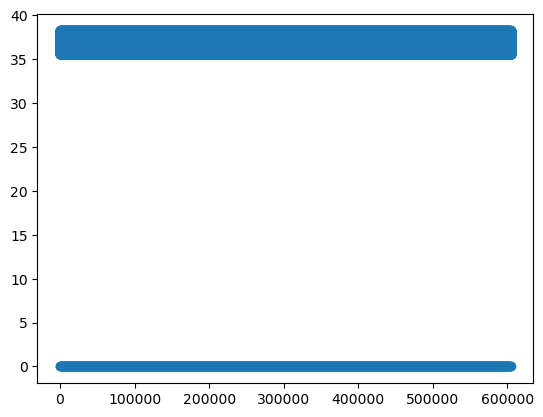

In [132]:
plt.scatter(Time_arr,JoulesOut_arr)

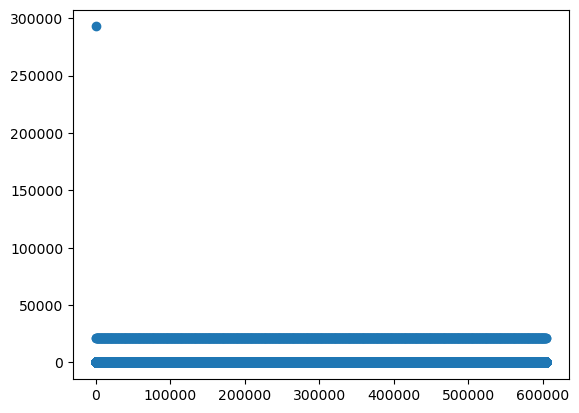

In [133]:
plt.scatter(Time_arr,JoulesIn_arr)

(0.0, 1000.0)

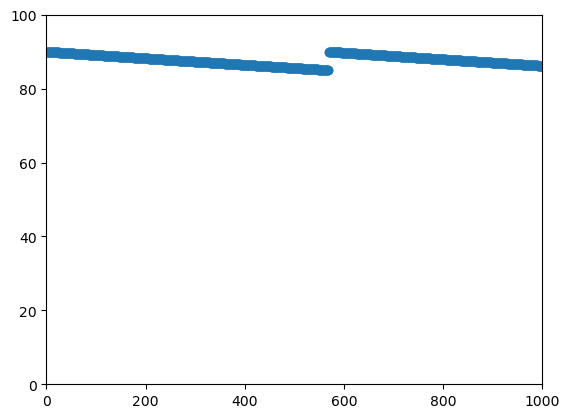

In [134]:
plt.scatter(Time_arr,np.array(SphereTemperature_arr)-273.15)
plt.ylim(0,100)
plt.xlim(0,1000)

In [135]:
TotalEnergyIn = np.sum(np.array(JoulesIn_arr)) # J
print(f"The total energy required was {round(TotalEnergyIn/1000,2)} kJ")

The total energy required was 22533.73 kJ


# Scenario 2 - Linear Polyester System (Conventional)

As pointed out in the comments made by the reviewer, one of the primary difference between the branching polyester system researched and that of a conventional
unsaturated polyester resin system would be the amounts of energy necessary for curing.

In the case of unsaturated polyester resins based on styrene, these can be initiated using unstable peroxides and their curing can be accelerated using other agents
such that they may even cure rapidly at room temperature. It is therefore the case that curing energy will always be lower for these materials.

I would, however, argue that this is a fairly unfair comparison: unsaturated polyester resins are based on a combination of prepolymer (linear unsaturated polyester)
and reactive diluent (e.g. styrene), the former having been polymerised in advance by a process known as 'cooking'.

This process of cooking, also known as melt polycondensation, can take around 12 hours and involves heating monomers at elevated temperatures between 150oC
and 210oC.

To estimate the amount of thermal energy that is spent on undertaking this procedure we will make many of the assumptions previously described, but will observe an
alternative 'cooking schedule', where temperature of the sphere will be periodically raised over a 12 hour window.

Arguably, only 60% of an unsaturated polyester resins mass stems from the the unsaturated polyester, the rest being reactive diluent. And since no mass losses take
place during curing we will reduce the mass undergoing heating to 60% by altering the mass down to 0.6kg.

In [136]:
DegreeCelsiusToKelvin = 273.15 # K
AmbientTemperature = 20+DegreeCelsiusToKelvin # K
Mass = 0.6 # kg
Density = 1000 # kg m^-3
Volume = Mass/Density # m^3
SphereRadius = (Volume/((4/3)*3.14159))**(1/3) # m
SphereSurfaceArea = 4*np.pi*(SphereRadius**2) # m^2
SpecificHeatCapacity = 4184 # J kg^-1 K^-1
OverallTransmissionCoefficient = 11.3 # W m^-2 K^-1

TargetTimes = [0,3600,7200,10800,14400,18000,21600,25200,28800,32400,36000,39600,43200]
TargetTime = TargetTimes[-1]
TargetTemperatures = [150,160,170,180,190,200,210,210,210,210,210,210] # oC
TargetTemperatures = np.array(TargetTemperatures)+DegreeCelsiusToKelvin # K
HysteresisVariable = 5 # K

In [137]:
Time_arr = []
SphereTemperature_arr = []
JoulesIn_arr = []
JoulesOut_arr = []

In [138]:
i = 0
while i < TargetTime:
    if i in TargetTimes:
        Time_arr.append(i) # 1
        Index = TargetTimes.index(i)
        if i == 0:
            InitialSphereTemperature = AmbientTemperature
        else:
            InitialSphereTemperature = SphereTemperature_arr[-1]
        FinalSphereTemperature = TargetTemperatures[Index]
        SphereTemperature_arr.append(FinalSphereTemperature) # 2
        TemperatureDifference = FinalSphereTemperature-InitialSphereTemperature
        EnergyDifference = SpecificHeatCapacityFormula_Energy(Mass,SpecificHeatCapacity,TemperatureDifference)
        JoulesIn_arr.append(EnergyDifference) # 3
        JoulesOut_arr.append(0) # 4
    else:
        for j in TargetTimes:
            if j-i < 0:
                continue
            else:
                break
        CurrentTargetTemperature = TargetTemperatures[TargetTimes.index(j)-1]
        if SphereTemperature_arr[-1] < (CurrentTargetTemperature-HysteresisVariable):
            Time_arr.append(i) # 1
            InitialSphereTemperature = SphereTemperature_arr[-1]
            FinalSphereTemperature = CurrentTargetTemperature
            SphereTemperature_arr.append(FinalSphereTemperature) # 2
            TemperatureDifference = FinalSphereTemperature-InitialSphereTemperature
            EnergyDifference = SpecificHeatCapacityFormula_Energy(Mass,SpecificHeatCapacity,TemperatureDifference)
            JoulesIn_arr.append(EnergyDifference) # 3
            JoulesOut_arr.append(0) # 4
        else:
            Time_arr.append(i) # 1
            InitialSphereTemperature = SphereTemperature_arr[-1]
            MassVsAirTemperatureDifference = InitialSphereTemperature-AmbientTemperature
            HeatLoss = HeatLossFormula_HeatLoss(OverallTransmissionCoefficient,SphereSurfaceArea,MassVsAirTemperatureDifference)
            TemperatureDifference = SpecificHeatCapacityFormula_TemperatureChange(HeatLoss,Mass,SpecificHeatCapacity)
            FinalSphereTemperature = InitialSphereTemperature-TemperatureDifference
            SphereTemperature_arr.append(FinalSphereTemperature) # 2
            JoulesIn_arr.append(0) # 3
            JoulesOut_arr.append(HeatLoss) # 4
    i+=1

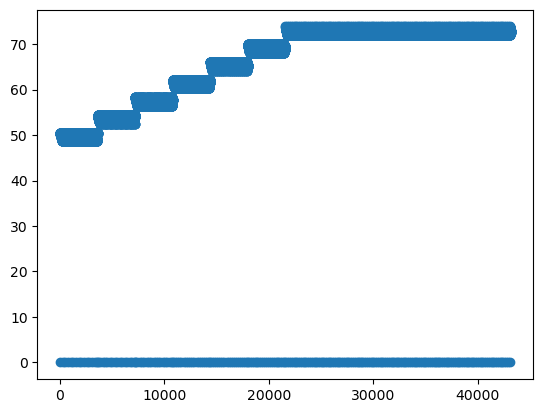

In [139]:
plt.scatter(Time_arr,JoulesOut_arr)

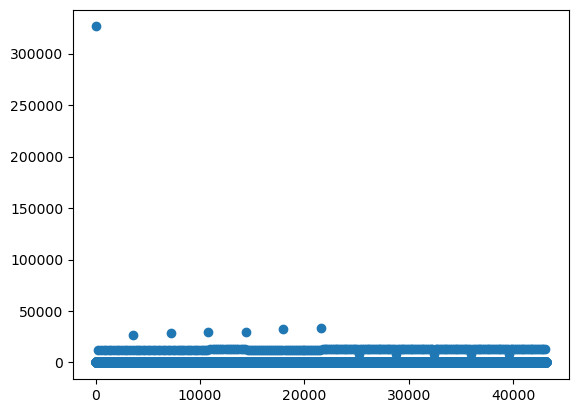

In [140]:
plt.scatter(Time_arr,JoulesIn_arr)

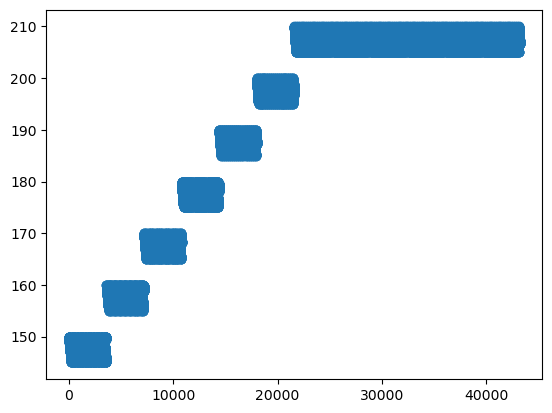

In [141]:
plt.scatter(Time_arr,np.array(SphereTemperature_arr)-273.15)

In [142]:
TotalEnergyIn = np.sum(np.array(JoulesIn_arr)) # J
print(f"The total energy required was {round(TotalEnergyIn/1000,2)} kJ")

The total energy required was 3308.07 kJ


# Comparison and FAQ

So, on initial comparison, we have a branched polyester system requiring 22,500 kJ and a linear unsaturated polyester resin system requiring 3,300 kJ.
That would make linear unsaturated polyester resin systems 15% of the thermal energetic cost of the branched system.

Would changes in mass of the reacting monomers have any impact on this comparison? Both lose around 20% of their mass through the process of polycondensation,
so it is unlikely.

Could there be differences in the energetic costs required to obtain the chemicals used as feedstocks in both of these systems? Yes. These will be manifold.
A list of assumed chemicals required for both systems is noted below in case someone were to want to take a crack at estimating their influence upon the analysis
presented here.

+ e.g. Branching System
Itaconic acid (25%), citric acid (25%), glycerol (50%).

+ e.g. Conventional Linear Unsaturated Polyester Resin
Styrene (60%), maleic acid (20%), propylene glycol (20%). (Inhibitors, intiators, and accelerators ignored.)